In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

In [5]:

data_path = Path('C:/Users/tsnmi/Downloads/AI_Job_Market_Trends_2026.csv')
df = pd.read_csv(data_path)

In [6]:
df.shape

(10345, 19)

In [7]:
df.head(20)

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2
5,6,Machine Learning Engineer,Medium,Technology,Australia,Onsite,Senior,6,Master,1,0,1,1,0,165878,5,2021,High,2
6,7,Data Scientist,MNC,Technology,Germany,Remote,Entry,14,Bachelor,0,0,0,0,0,67027,8,2026,High,8
7,8,Data Analyst,Enterprise,Finance,UK,Onsite,Entry,4,PhD,1,0,1,0,1,78392,8,2023,High,7
8,9,Machine Learning Engineer,Startup,Education,Canada,Onsite,Mid,2,PhD,0,0,0,0,1,123840,5,2021,Low,3
9,10,Data Engineer,Enterprise,Retail,USA,Onsite,Senior,9,Master,1,0,0,0,1,112408,4,2024,High,7


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_id                10345 non-null  int64
 1   job_title             10345 non-null  str  
 2   company_size          10345 non-null  str  
 3   company_industry      10345 non-null  str  
 4   country               10345 non-null  str  
 5   remote_type           10345 non-null  str  
 6   experience_level      10345 non-null  str  
 7   years_experience      10345 non-null  int64
 8   education_level       10345 non-null  str  
 9   skills_python         10345 non-null  int64
 10  skills_sql            10345 non-null  int64
 11  skills_ml             10345 non-null  int64
 12  skills_deep_learning  10345 non-null  int64
 13  skills_cloud          10345 non-null  int64
 14  salary                10345 non-null  int64
 15  job_posting_month     10345 non-null  int64
 16  job_posting_yea

In [9]:
num_cols = df.select_dtypes(include='number').columns
print("NUmber of Numeric Columns:", len(num_cols))
print("Numeric Columns: ", list(num_cols))

NUmber of Numeric Columns: 11
Numeric Columns:  ['job_id', 'years_experience', 'skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month', 'job_posting_year', 'job_openings']


In [10]:
calculation = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Mode':df[num_cols].mode().iloc[0],
    'std dev': df[num_cols].std(),
    'IQR': df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
})
calculation

,Mean,Median,Mode,std dev,IQR
job_id,5173.000000,5173.0,1.0,2986.488601,5172.0
years_experience,6.950507,7.0,5.0,4.320054,8.0
skills_python,0.493088,0.0,0.0,0.499976,1.0
skills_sql,0.503045,1.0,1.0,0.500015,1.0
skills_ml,0.507878,1.0,1.0,0.499962,1.0
skills_deep_learning,0.498018,0.0,0.0,0.500020,1.0
skills_cloud,0.511455,1.0,1.0,0.499893,1.0
salary,113438.227260,113082.0,70512.0,31389.201060,45179.0
job_posting_month,6.502465,6.0,1.0,3.473441,6.0
job_posting_year,2023.000387,2023.0,2024.0,1.996856,4.0


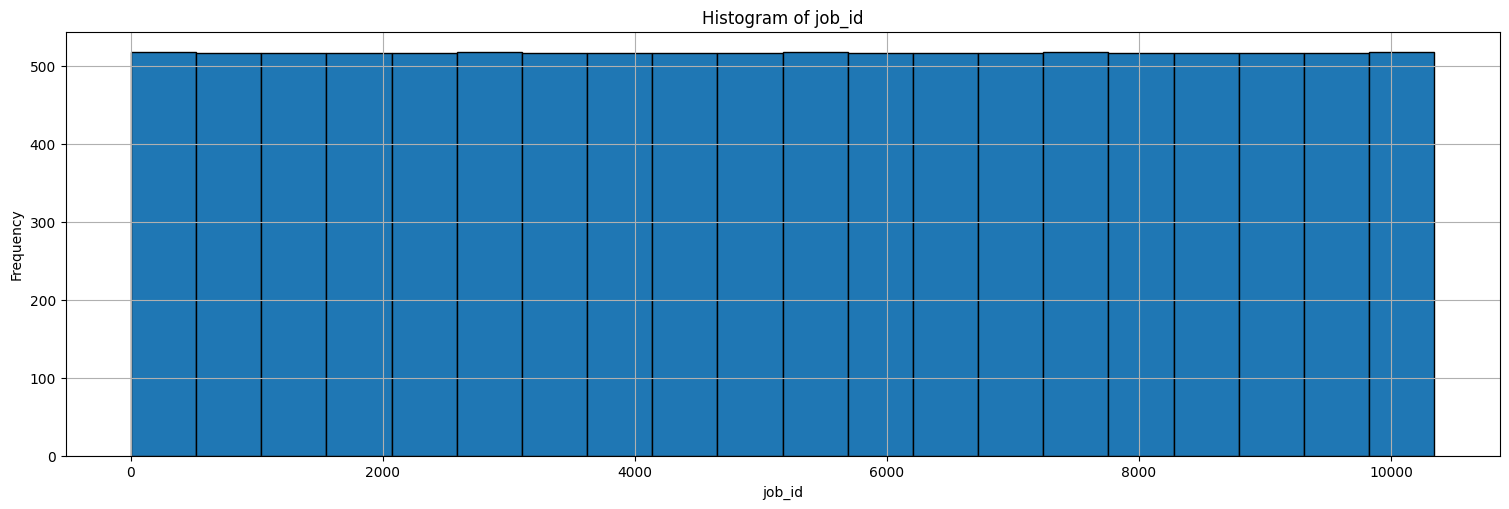

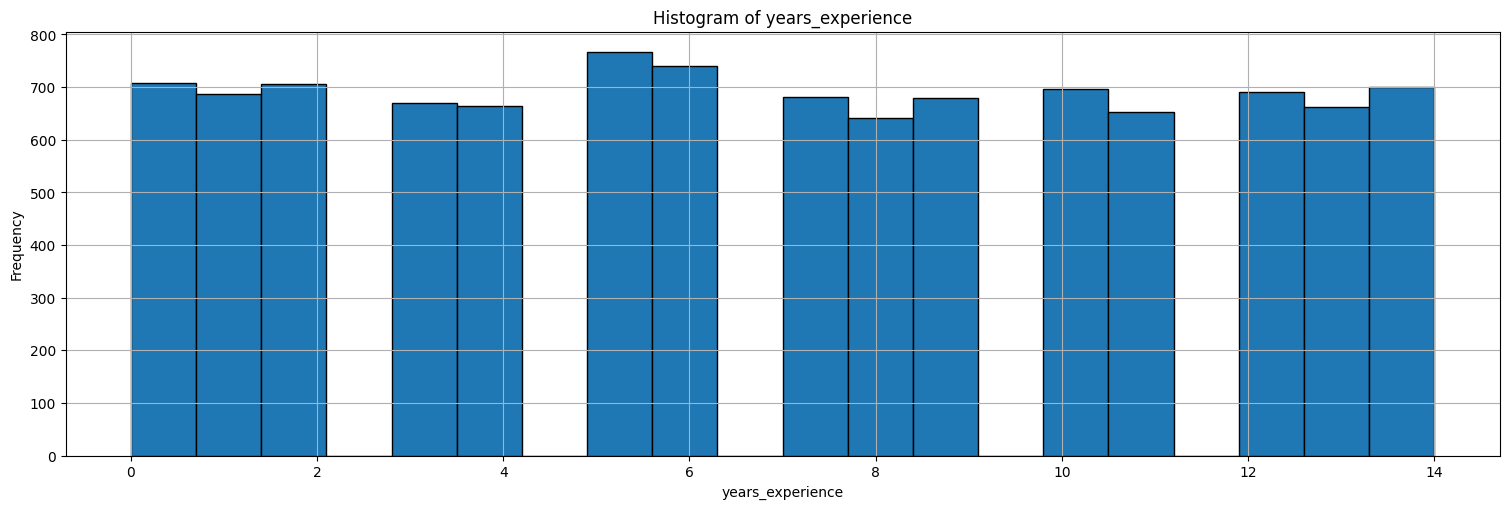

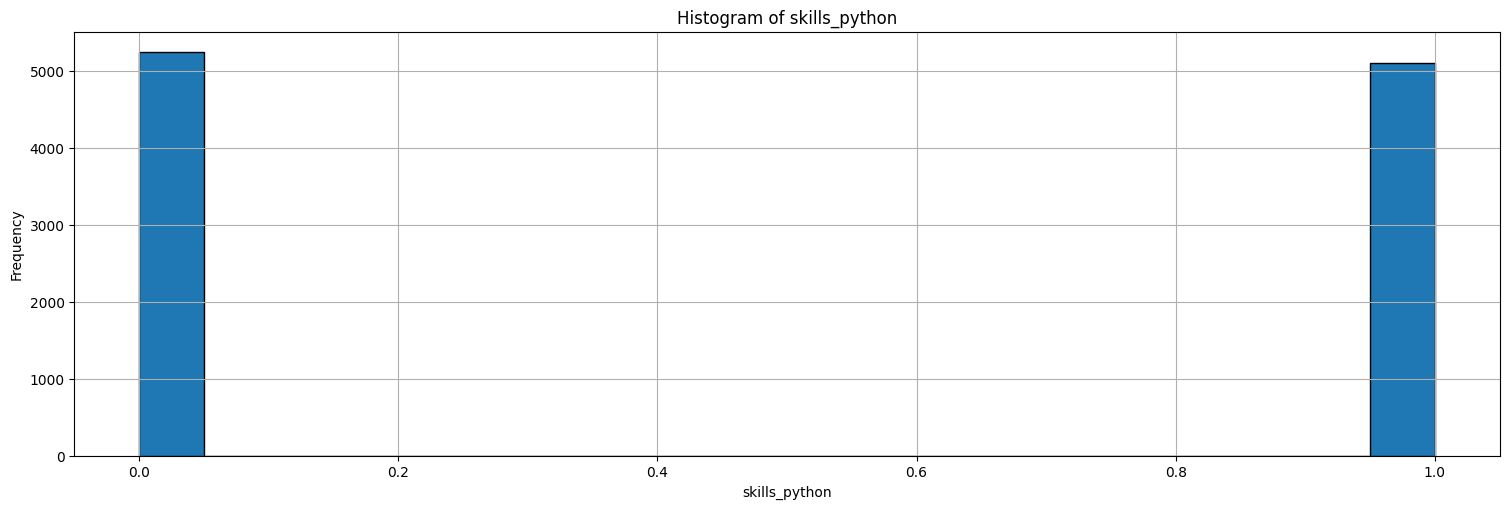

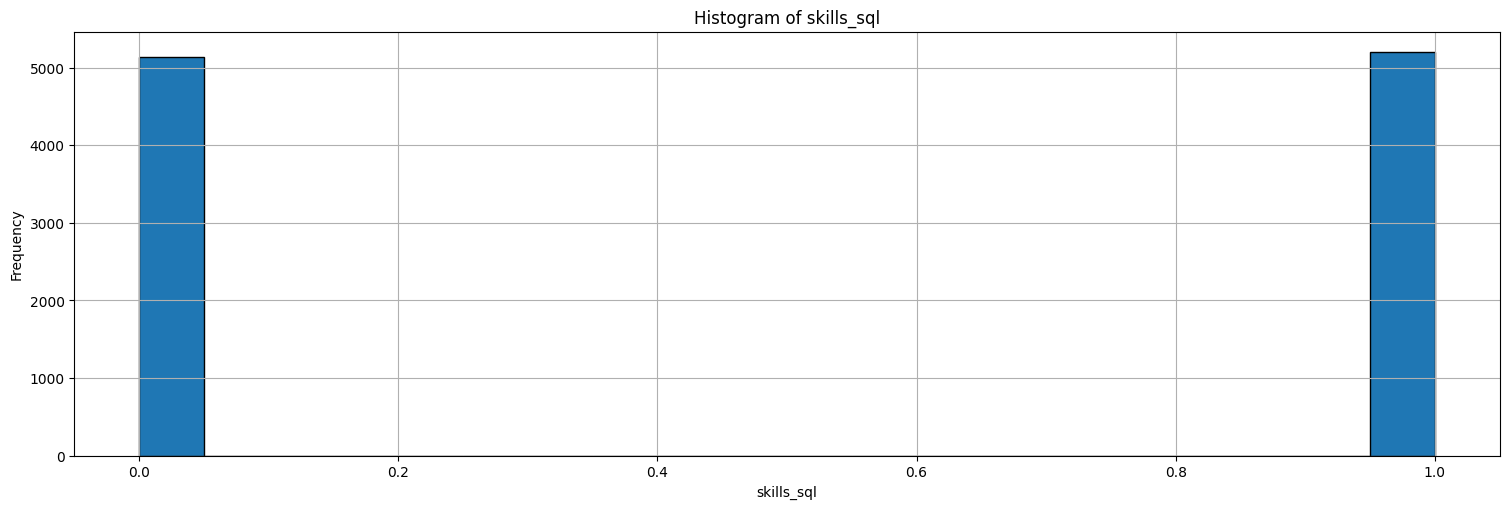

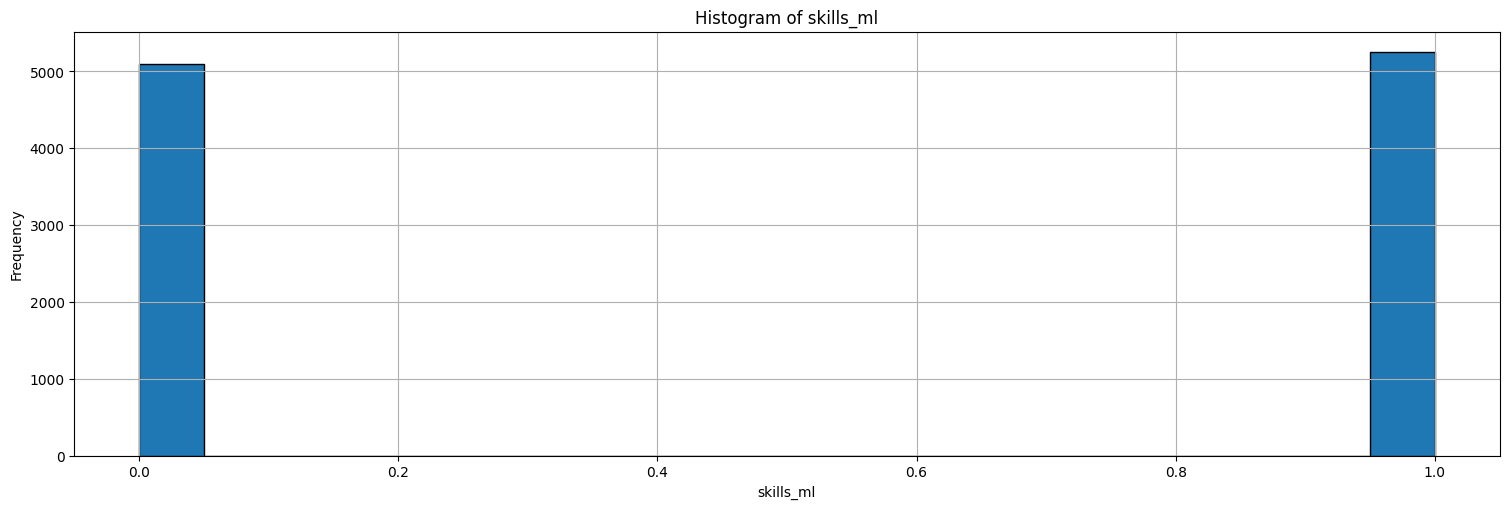

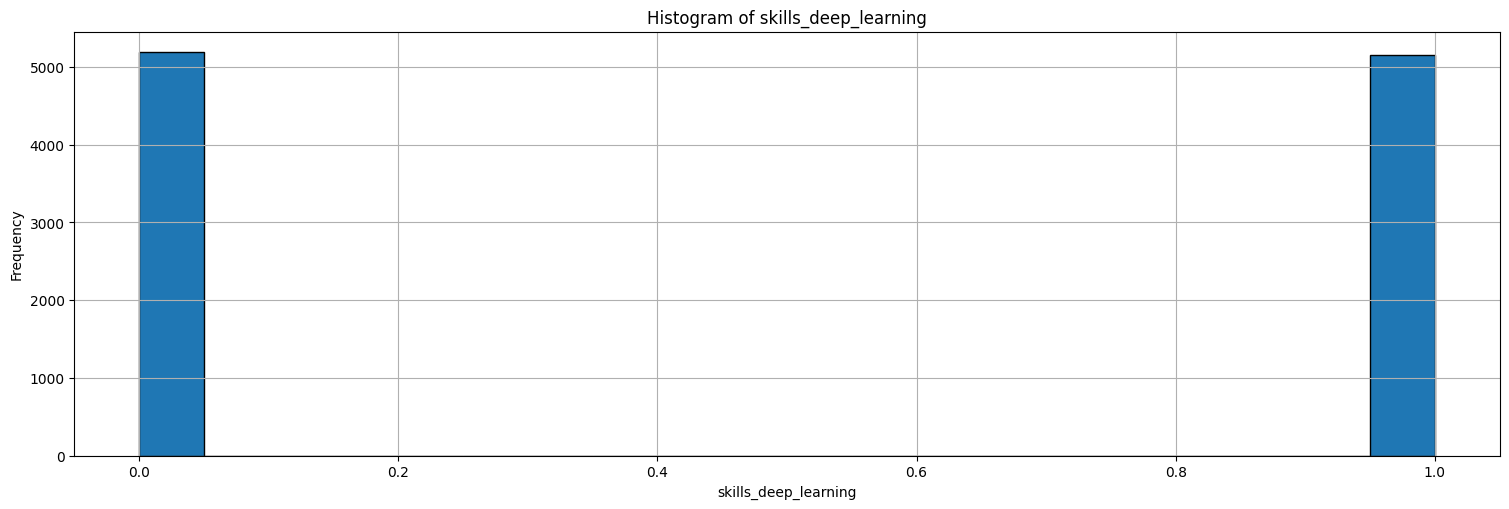

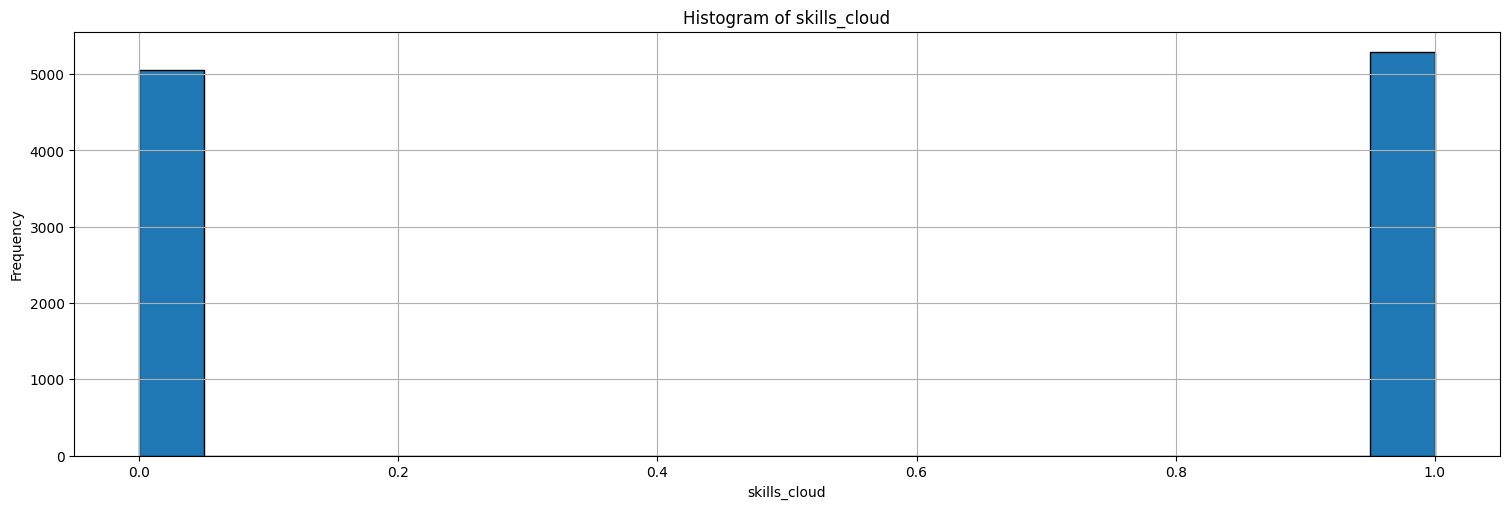

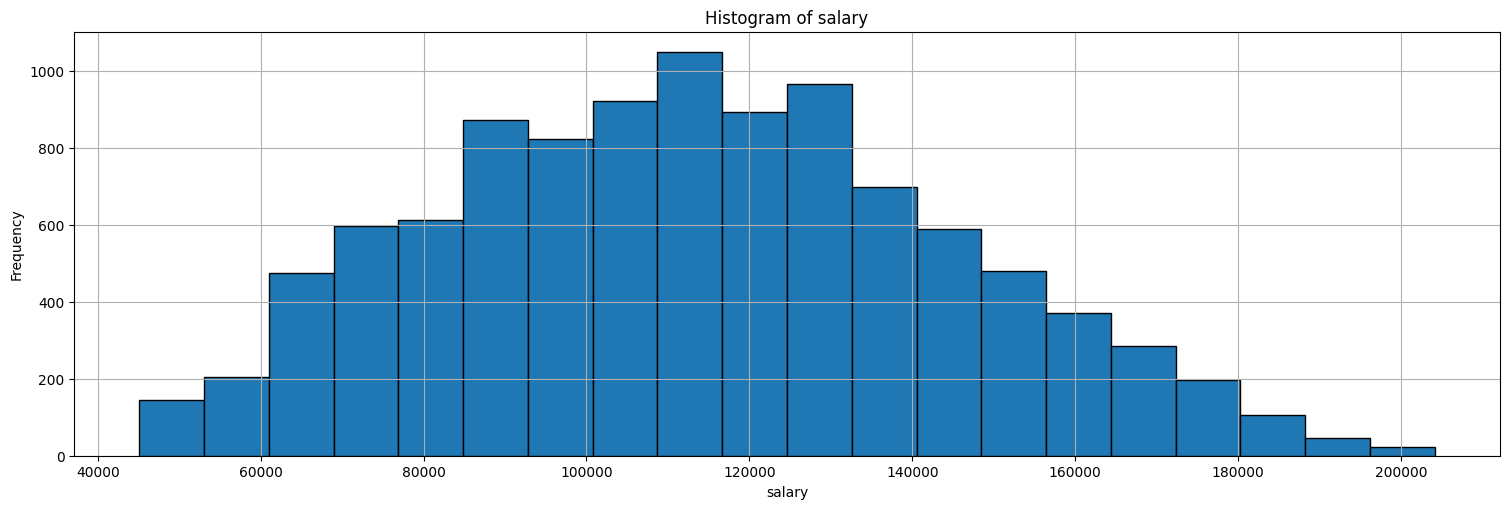

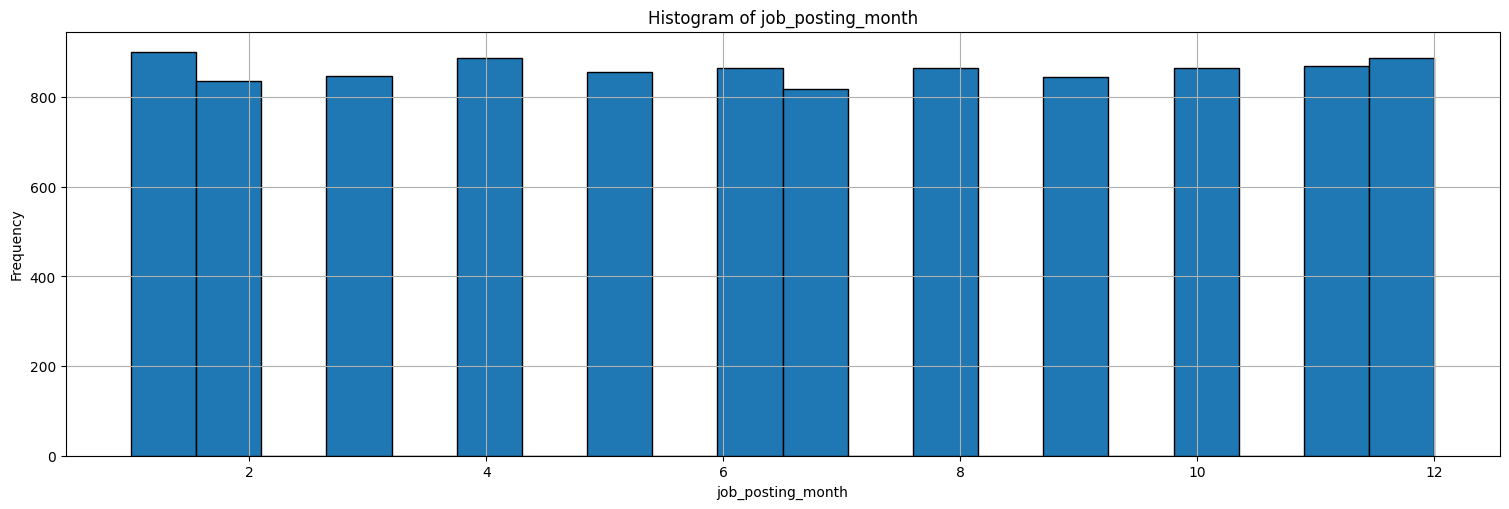

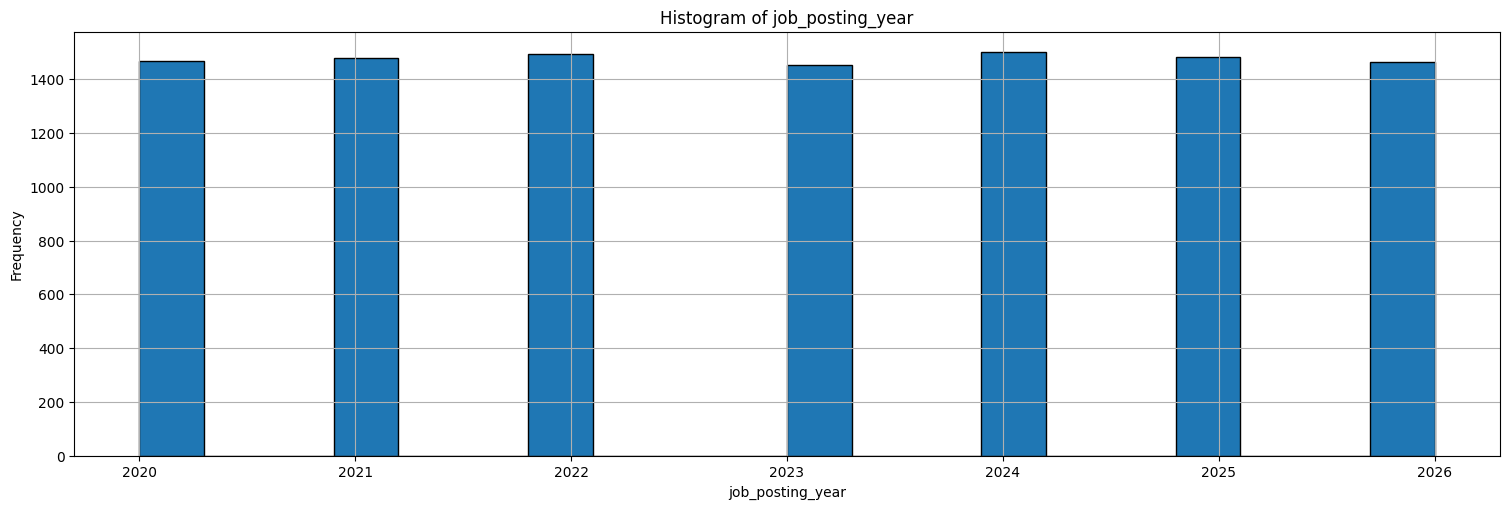

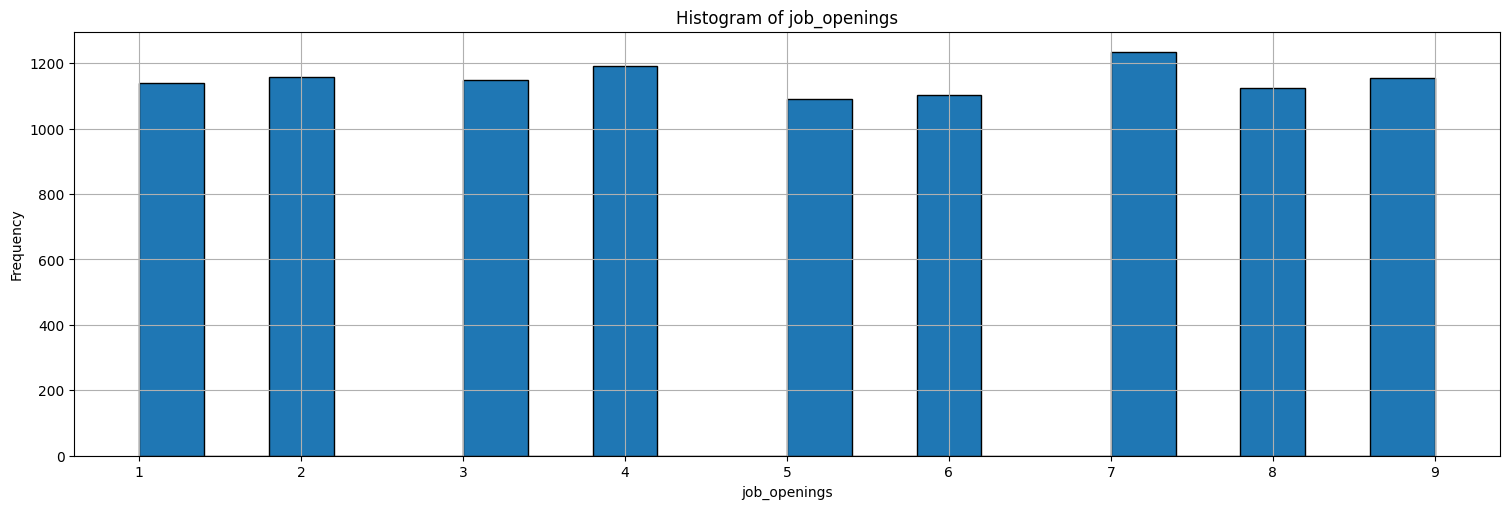

In [13]:
for col in num_cols:
    plt.figure()
    df[col].hist(bins=20,edgecolor='black',figsize=(15,5))
    plt.title(f'Histogram of {col}')
    plt.tight_layout()
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

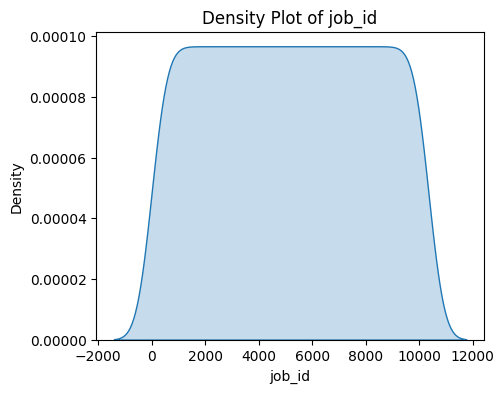

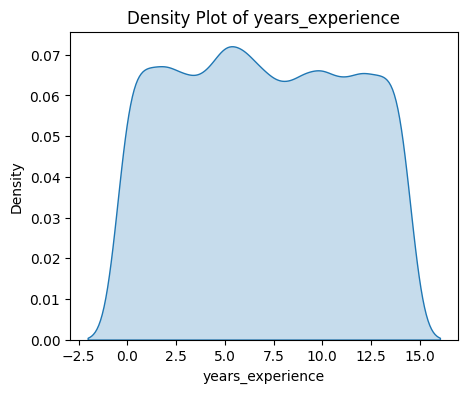

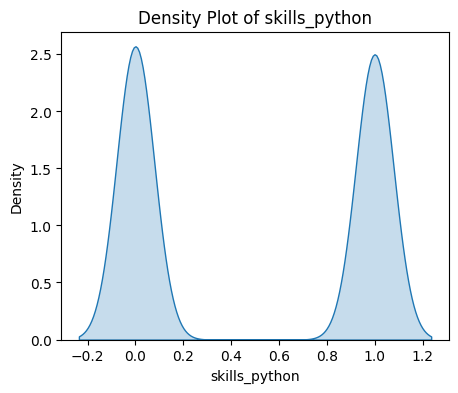

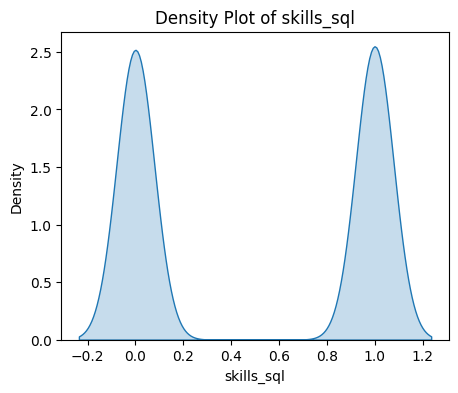

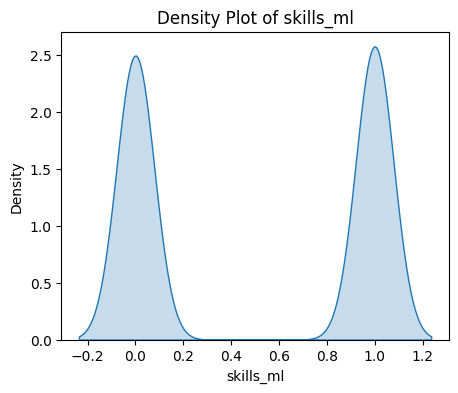

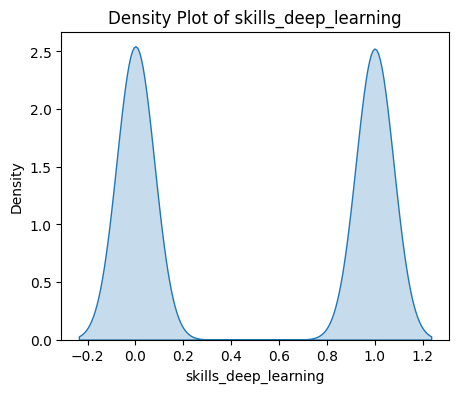

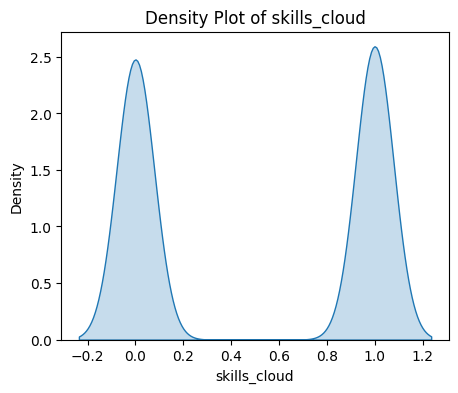

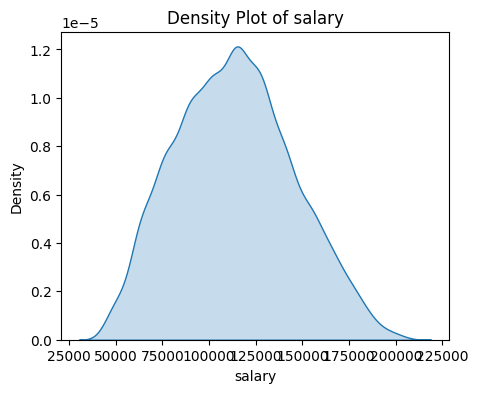

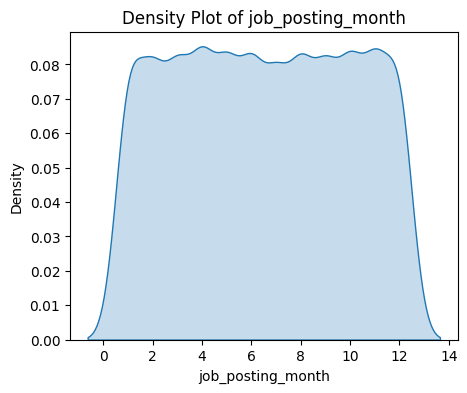

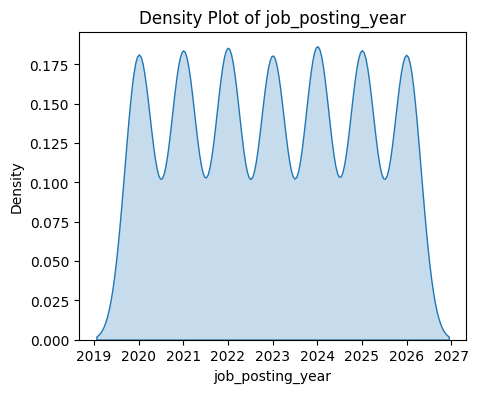

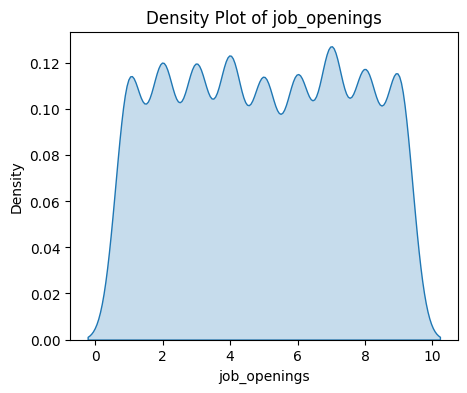

In [21]:
for col in num_cols:
    plt.figure(figsize=(5, 4))
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Density Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

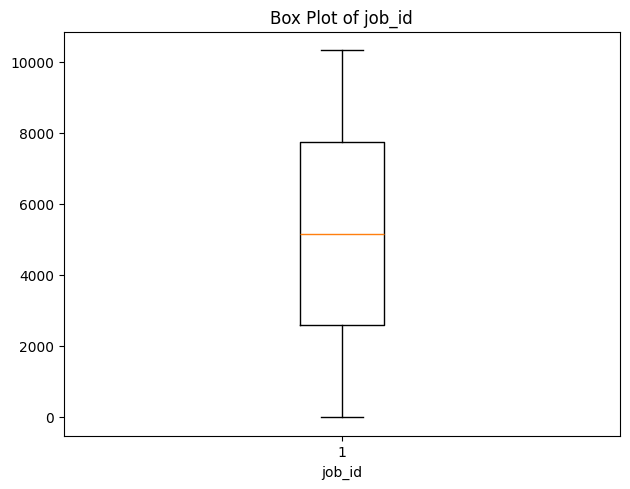

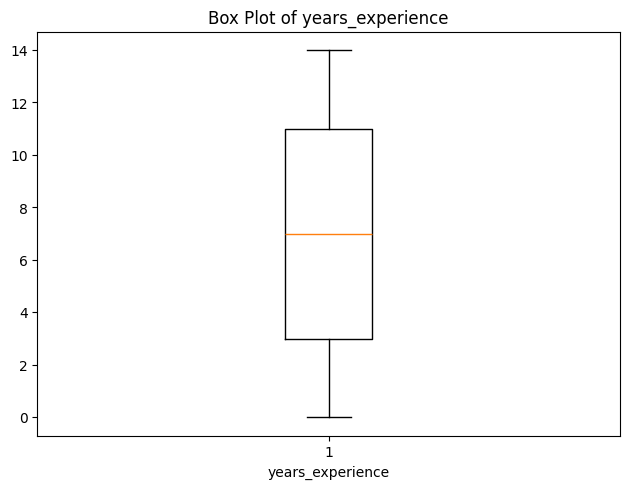

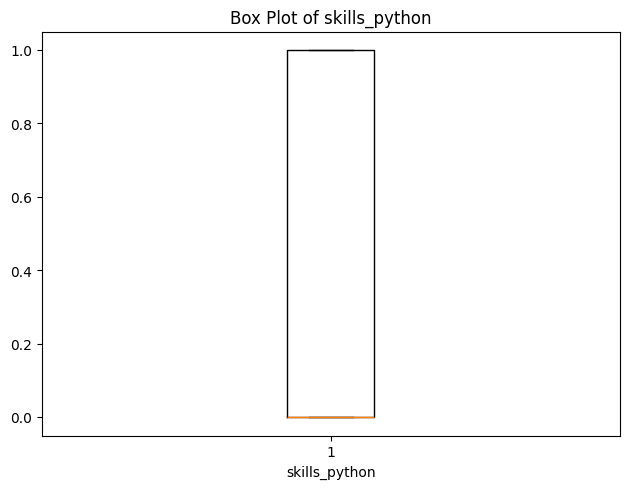

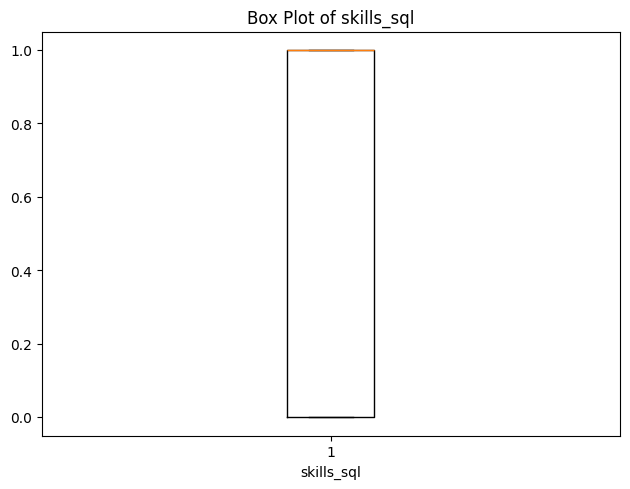

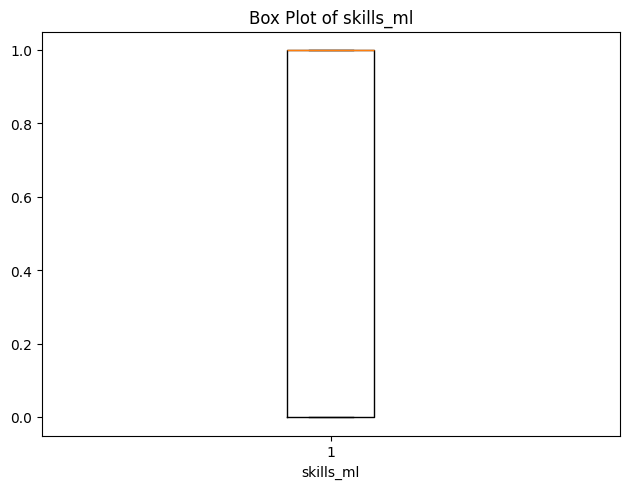

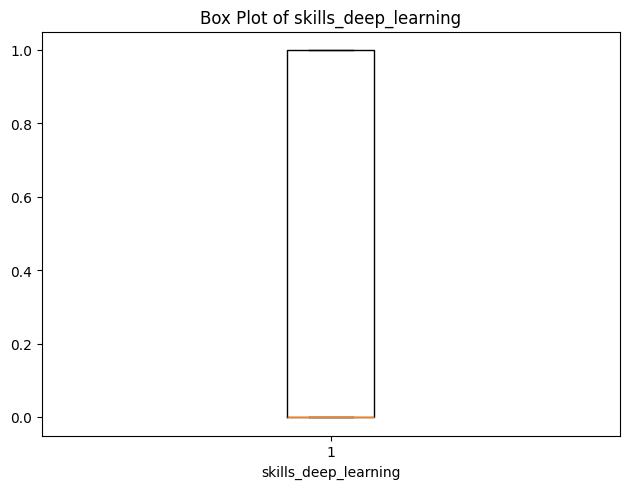

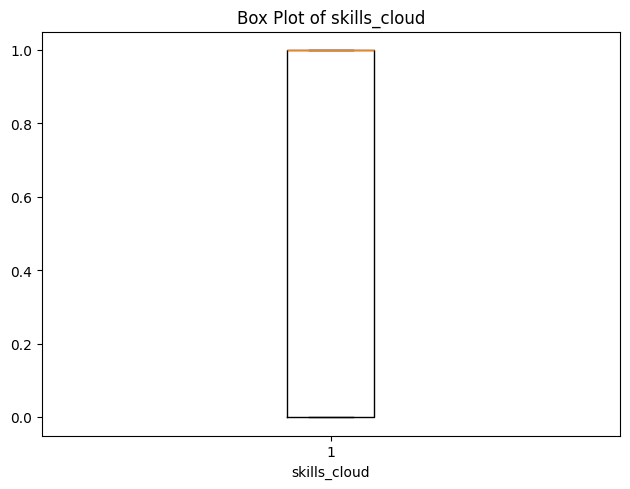

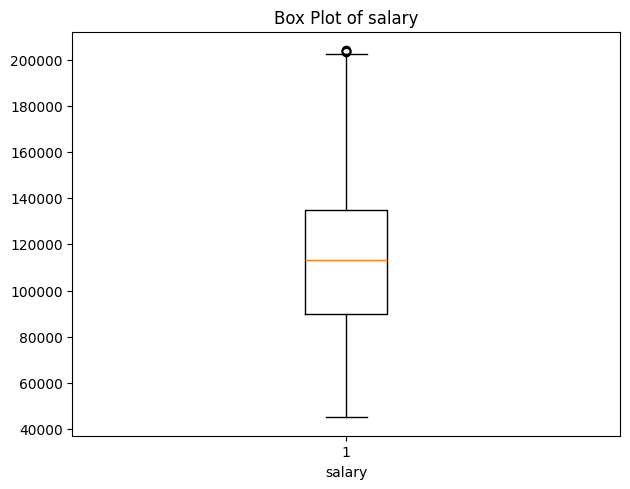

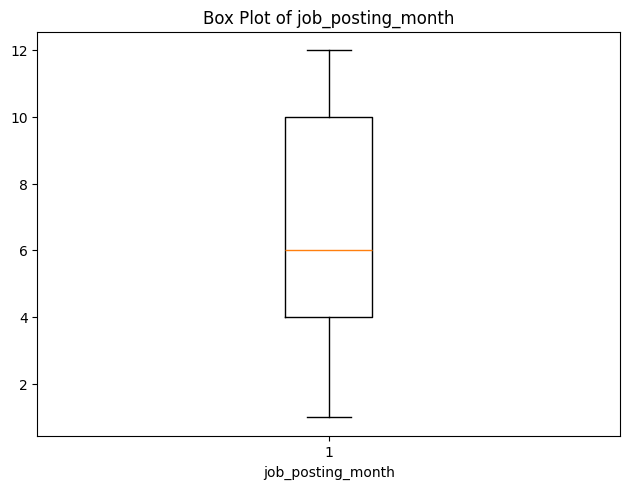

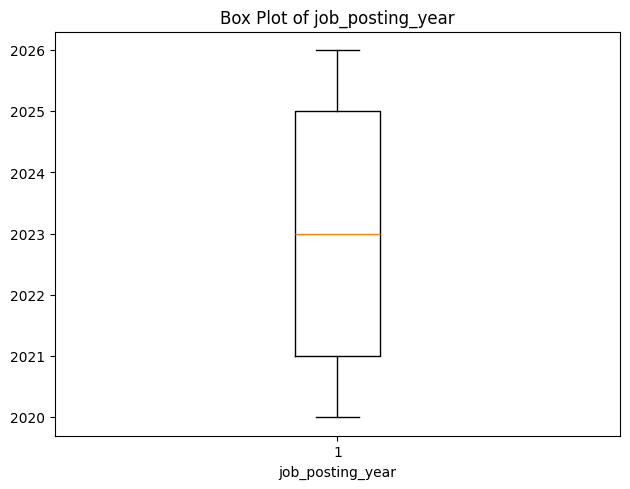

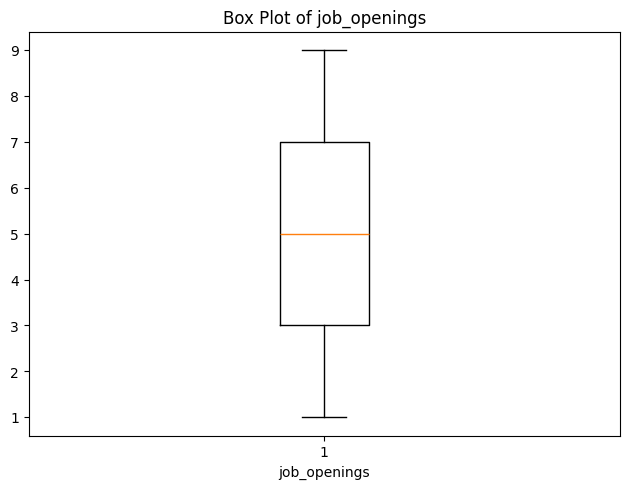

In [23]:
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
    plt.tight_layout()
    plt.xlabel(col)
    plt.show()

In [40]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3-Q1
outliers = df[(df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))]
print(outliers[num_cols].count())

job_id                  0
years_experience        0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  4
job_posting_month       0
job_posting_year        0
job_openings            0
dtype: int64


In [31]:
skewness = df[num_cols].skew()
skewness_df = pd.DataFrame({
    "Feature": skewness.index,
    "skewness": skewness.values
})
skewness_df

,Feature,skewness
0,job_id,0.000000
1,years_experience,0.021876
2,skills_python,0.027653
3,skills_sql,-0.012182
4,skills_ml,-0.031521
5,skills_deep_learning,0.007928
6,skills_cloud,-0.045838
7,salary,0.179371
8,job_posting_month,0.000142
9,job_posting_year,-0.001042


In [33]:
cat_cols = df.select_dtypes(include = ["object","str"]).columns
print("Number of Categorical Columns:", len(cat_cols))
print("Categorical Columns: ", list(cat_cols))

Number of Categorical Columns: 8
Categorical Columns:  ['job_title', 'company_size', 'company_industry', 'country', 'remote_type', 'experience_level', 'education_level', 'hiring_urgency']


In [42]:
for col in cat_cols:
    print(f"Frequency table for: {col}")
    freq_table = df[col].value_counts().reset_index()
    freq_table.columns = ['Category','Count']
    
    print(freq_table.to_string(index=False))

Frequency table for: job_title
                 Category  Count
         Business Analyst   1773
              AI Engineer   1742
Machine Learning Engineer   1740
             Data Analyst   1711
           Data Scientist   1703
            Data Engineer   1676
Frequency table for: company_size
  Category  Count
   Startup   2656
       MNC   2593
    Medium   2548
Enterprise   2548
Frequency table for: company_industry
  Category  Count
Technology   1787
E-commerce   1744
   Finance   1724
Healthcare   1715
 Education   1704
    Retail   1671
Frequency table for: country
 Category  Count
  Germany   1498
Singapore   1490
   Canada   1488
       UK   1485
    India   1470
      USA   1459
Australia   1455
Frequency table for: remote_type
Category  Count
  Remote   3513
  Hybrid   3420
  Onsite   3412
Frequency table for: experience_level
Category  Count
   Entry   3513
  Senior   3420
     Mid   3412
Frequency table for: education_level
Category  Count
  Master   3529
     PhD   3425
B

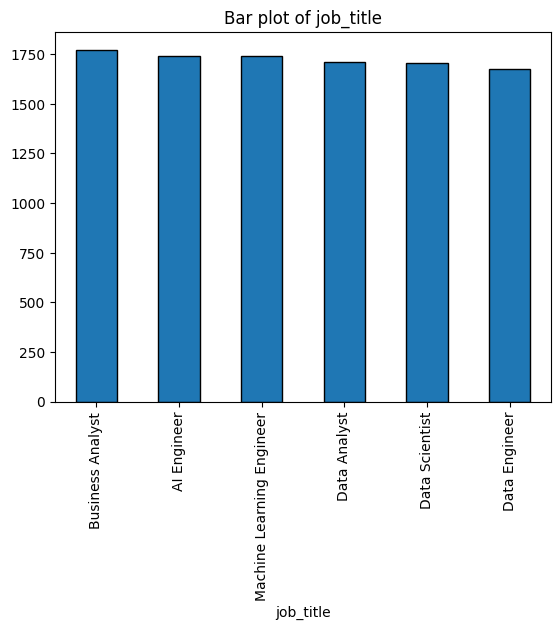

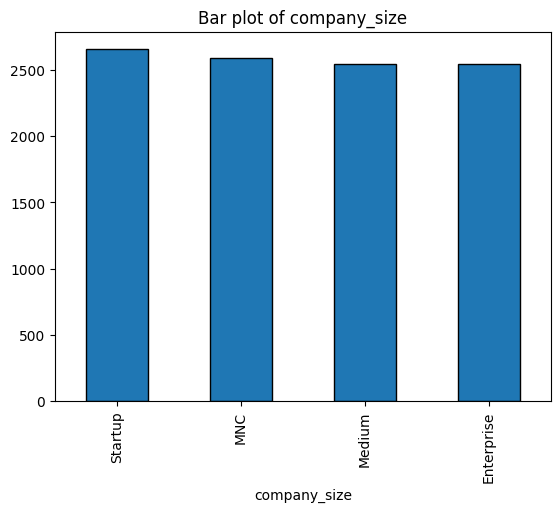

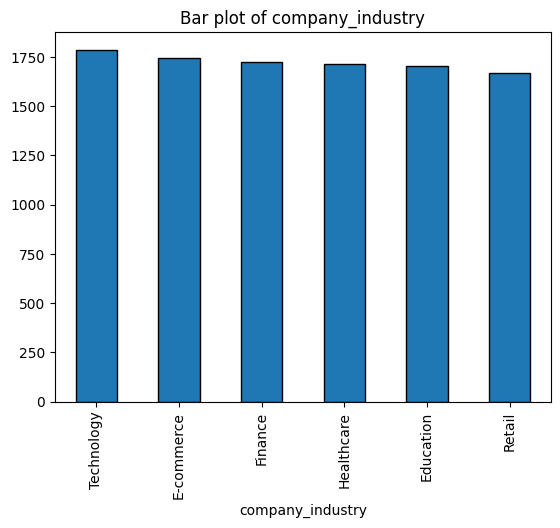

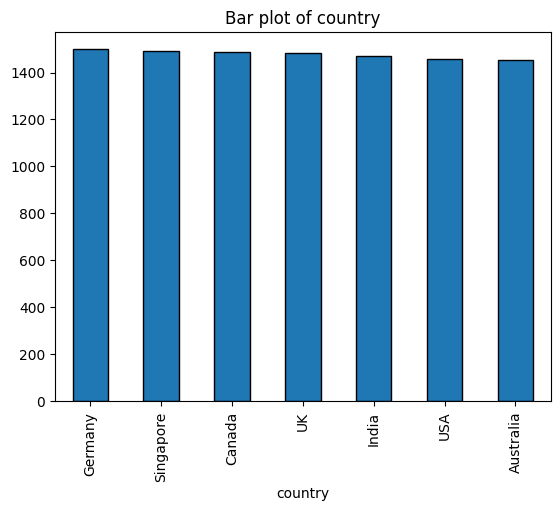

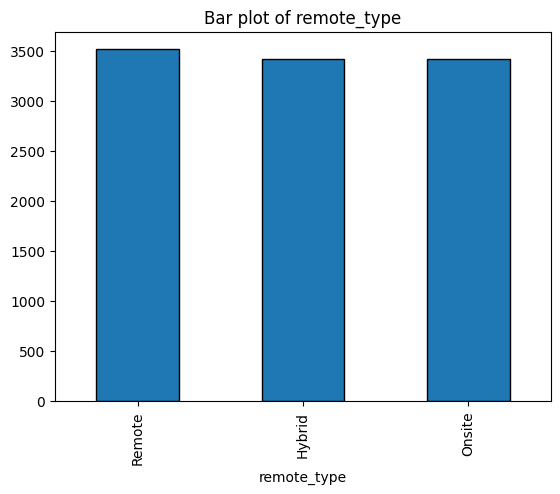

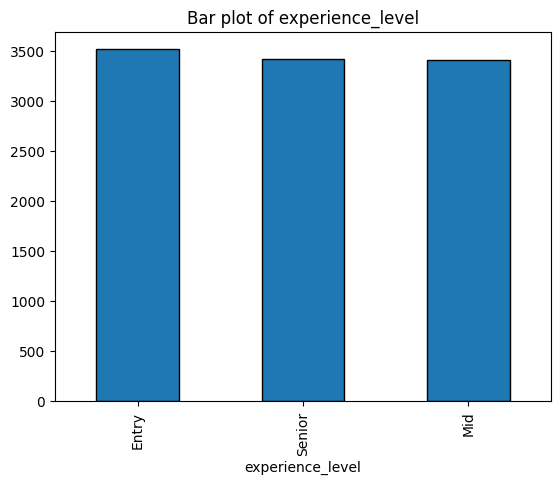

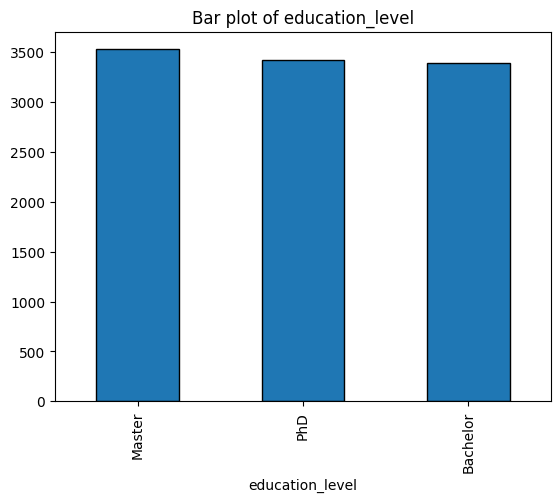

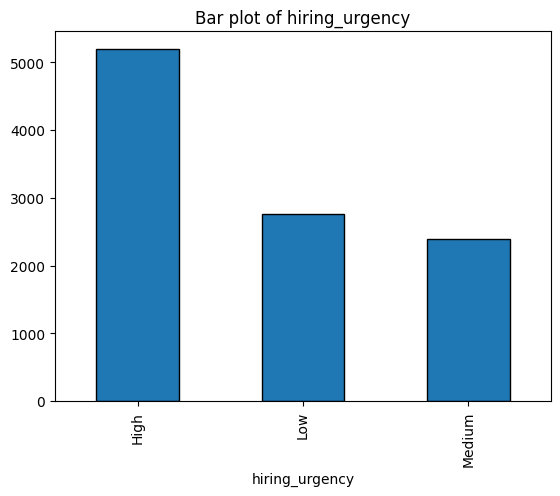

In [43]:
for col in cat_cols:
    plt.figure()
    plt.title(f"Bar plot of {col}")
    df[col].value_counts().plot(kind='bar', edgecolor='black')
    plt.show()

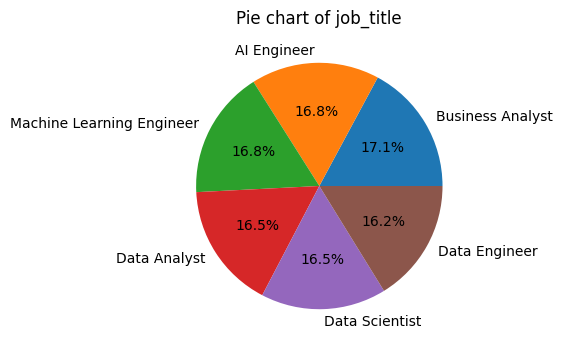

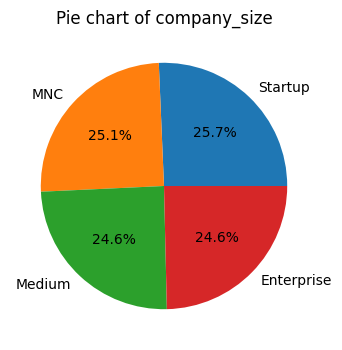

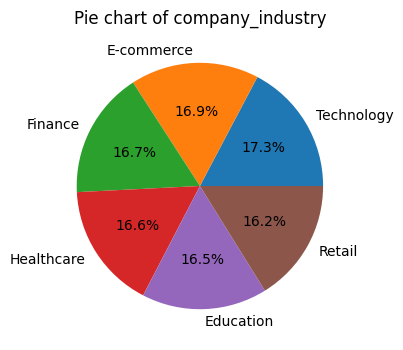

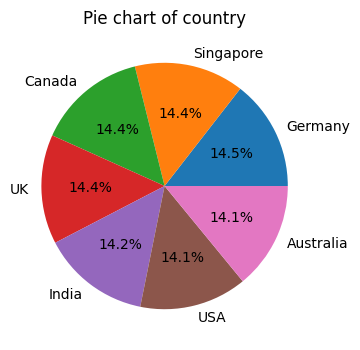

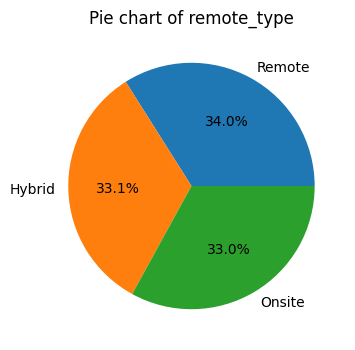

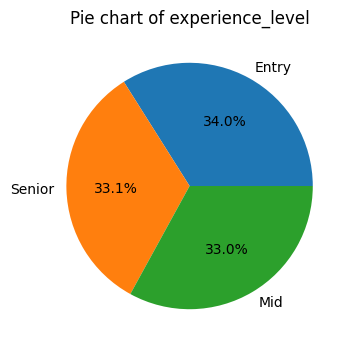

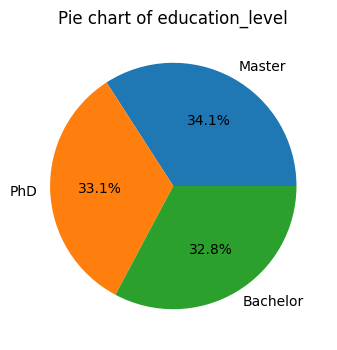

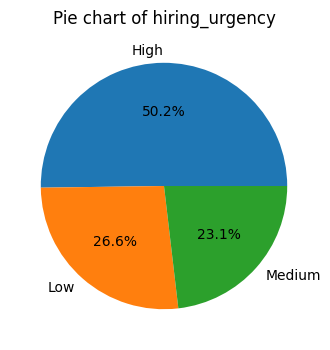

In [49]:
for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%',
        figsize=(5,4)
    )
    plt.title(f"Pie chart of {col}")
    plt.ylabel('')
    plt.show()

In [51]:
num_cols

Index(['job_id', 'years_experience', 'skills_python', 'skills_sql',
       'skills_ml', 'skills_deep_learning', 'skills_cloud', 'salary',
       'job_posting_month', 'job_posting_year', 'job_openings'],
      dtype='str')

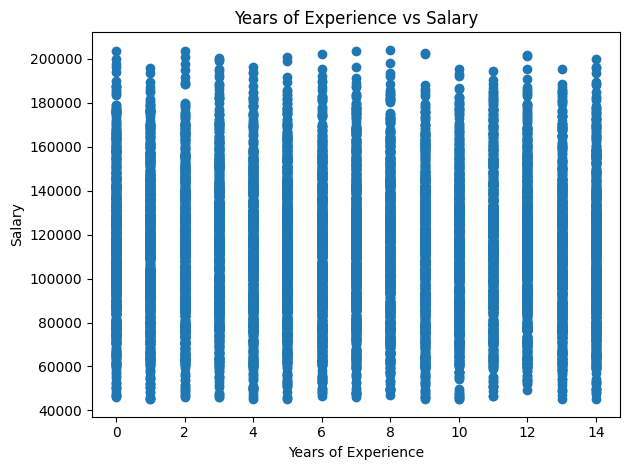

In [ ]:
plt.scatter(df['years_experience'],df['salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title("Years of Experience vs Salary")
plt.tight_layout()
plt.show()

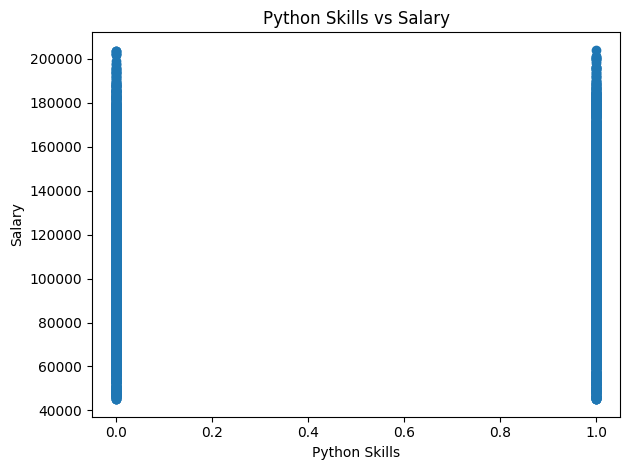

In [54]:
plt.scatter(df['skills_python'],df['salary'])
plt.xlabel('Python Skills')
plt.ylabel('Salary')
plt.title("Python Skills vs Salary")
plt.tight_layout()
plt.show()

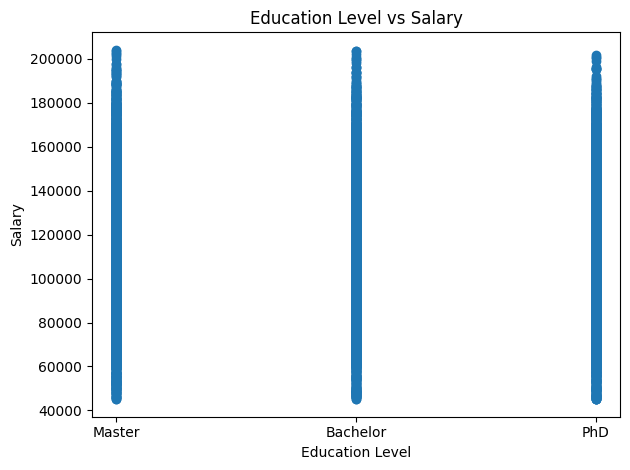

In [55]:
plt.scatter(df['education_level'],df['salary'])
plt.xlabel('Education Level')
plt.ylabel('Salary')
plt.title("Education Level vs Salary")
plt.tight_layout()
plt.show()

In [56]:
df.isnull().sum()

job_id                  0
job_title               0
company_size            0
company_industry        0
country                 0
remote_type             0
experience_level        0
years_experience        0
education_level         0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  0
job_posting_month       0
job_posting_year        0
hiring_urgency          0
job_openings            0
dtype: int64

In [57]:
df.duplicated().sum()

np.int64(0)